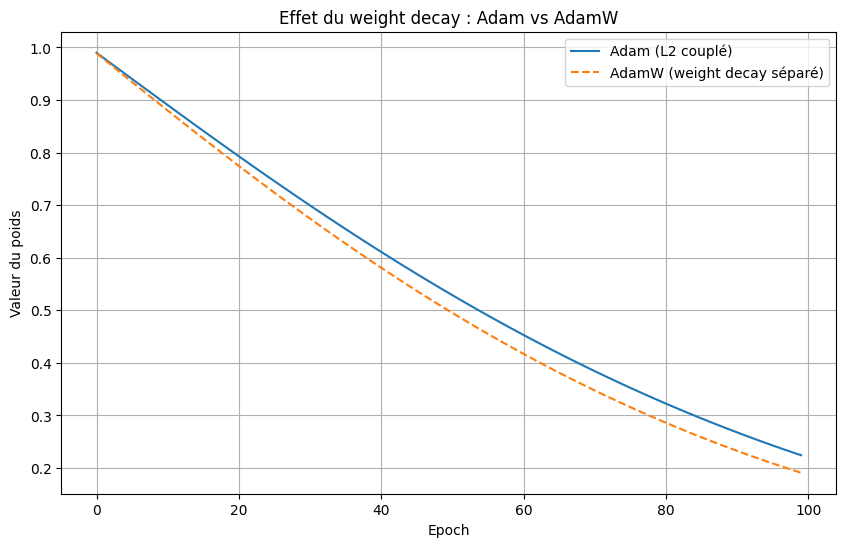

In [2]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam, AdamW
import matplotlib.pyplot as plt

# Paramètres
epochs = 100
lr = 0.01
weight_decay = 0.1

# Poids initiaux
w_adam = tf.Variable(1.0)
w_adamw = tf.Variable(1.0)

opt_adam = Adam(learning_rate=lr)
opt_adamw = AdamW(learning_rate=lr, weight_decay=weight_decay)

# Historique
adam_weights = []
adamw_weights = []

# Fonction de perte : simple courbe en U
def loss_fn(w):
    return w ** 2

for epoch in range(epochs):
    # Adam classique
    with tf.GradientTape() as tape:
        loss = loss_fn(w_adam)
    grads = tape.gradient(loss, [w_adam])
    opt_adam.apply_gradients(zip(grads, [w_adam]))
    adam_weights.append(w_adam.numpy())

    # AdamW
    with tf.GradientTape() as tape:
        loss = loss_fn(w_adamw)
    grads = tape.gradient(loss, [w_adamw])
    opt_adamw.apply_gradients(zip(grads, [w_adamw]))
    adamw_weights.append(w_adamw.numpy())

# Affichage
plt.figure(figsize=(10, 6))
plt.plot(adam_weights, label='Adam (L2 couplé)')
plt.plot(adamw_weights, label='AdamW (weight decay séparé)', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Valeur du poids')
plt.title('Effet du weight decay : Adam vs AdamW')
plt.legend()
plt.grid(True)
plt.show()